In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings 
warnings.filterwarnings('ignore')

# Business problem statement
### A company advertises the same campaigns on two channels — Facebook Ads and Google AdWords — and has a limited marketing budget. Management needs to know: which platform delivers better ad performance (clicks, conversions, cost-efficiency), so budget can be allocated to the higher-performing channel — backed by statistical evidence, not just gut feeling or raw averages.

# Loading data 

In [2]:
df=pd.read_csv(r"C:\Users\rakesh kumar\OneDrive\Desktop\AB Testing project\A_B_testing_dataset.csv")
df

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-12-17,FACEBOOK AD,1154,56,8,161,4.85,14.29,2.88,ADWORD AD,4275,73,3,54,1.71,4.11,0.74
996,2024-12-18,FACEBOOK AD,1108,58,13,198,5.23,22.41,3.41,ADWORD AD,4749,55,5,116,1.16,9.09,2.11
997,2024-12-18,FACEBOOK AD,1866,70,19,97,3.75,27.14,1.39,ADWORD AD,4582,36,4,149,0.79,11.11,4.14
998,2024-12-20,FACEBOOK AD,1279,59,19,171,4.61,32.20,2.90,ADWORD AD,4877,66,6,65,1.35,9.09,0.98


In [3]:
df.head()

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date_of_campaign          1000 non-null   object 
 1   facebook_ad_campaign      1000 non-null   object 
 2   facebook_ad_views         1000 non-null   int64  
 3   facebook_ad_clicks        1000 non-null   int64  
 4   facebook_ad_conversions   1000 non-null   int64  
 5   facebook_cost_per_ad      1000 non-null   int64  
 6   facebook_ctr              1000 non-null   float64
 7   facebook_conversion_rate  1000 non-null   float64
 8   facebook_cost_per_click   1000 non-null   float64
 9   adword_ad_campaign        1000 non-null   object 
 10  adword_ad_views           1000 non-null   int64  
 11  adword_ad_clicks          1000 non-null   int64  
 12  adword_ad_conversions     1000 non-null   int64  
 13  adword_cost_per_ad        1000 non-null   int64  
 14  adword_ct

In [5]:
df.duplicated().sum()

0

# EDA
# Data cleaning 

In [6]:
df["date_of_campaign"] = pd.to_datetime(df["date_of_campaign"])

In [7]:
df["date_of_campaign"].is_monotonic_increasing

True

In [8]:
df["year"] = df["date_of_campaign"].dt.year
df["month"] = df["date_of_campaign"].dt.month
df["year_month"] = df["date_of_campaign"].dt.to_period("M").astype(str)

In [9]:
df

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click,year,month,year_month
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77,2021,12,2021-12
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74,2021,12,2021-12
2,2021-12-25,FACEBOOK AD,1936,53,15,66,2.74,28.30,1.25,ADWORD AD,4702,38,9,187,0.81,23.68,4.92,2021,12,2021-12
3,2021-12-25,FACEBOOK AD,1194,45,9,71,3.77,20.00,1.58,ADWORD AD,3718,58,3,161,1.56,5.17,2.78,2021,12,2021-12
4,2021-12-26,FACEBOOK AD,2479,44,12,174,1.77,27.27,3.95,ADWORD AD,5562,63,4,162,1.13,6.35,2.57,2021,12,2021-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-12-17,FACEBOOK AD,1154,56,8,161,4.85,14.29,2.88,ADWORD AD,4275,73,3,54,1.71,4.11,0.74,2024,12,2024-12
996,2024-12-18,FACEBOOK AD,1108,58,13,198,5.23,22.41,3.41,ADWORD AD,4749,55,5,116,1.16,9.09,2.11,2024,12,2024-12
997,2024-12-18,FACEBOOK AD,1866,70,19,97,3.75,27.14,1.39,ADWORD AD,4582,36,4,149,0.79,11.11,4.14,2024,12,2024-12
998,2024-12-20,FACEBOOK AD,1279,59,19,171,4.61,32.20,2.90,ADWORD AD,4877,66,6,65,1.35,9.09,0.98,2024,12,2024-12


In [10]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date_of_campaign,1000,2023-07-04 07:13:26.399999744,2021-12-22 00:00:00,2022-10-07 18:00:00,2023-07-20 12:00:00,2024-03-24 00:00:00,2024-12-20 00:00:00,NaN
facebook_ad_views,1000.0,2152.031,1050.0,1600.25,2123.5,2706.25,3320.0,661.982166
facebook_ad_clicks,1000.0,44.196,15.0,30.0,44.5,58.0,73.0,16.833328
facebook_ad_conversions,1000.0,11.975,5.0,8.0,12.0,16.0,19.0,4.298471
facebook_cost_per_ad,1000.0,156.61,60.0,110.0,156.0,205.0,250.0,54.918904
facebook_ctr,1000.0,2.28316,0.49,1.3675,2.07,2.9225,6.86,1.2067
facebook_conversion_rate,1000.0,32.69608,6.85,18.0525,27.12,41.88,118.75,20.570796
facebook_cost_per_click,1000.0,4.3105,0.96,2.3375,3.6,5.61,16.53,2.751582
adword_ad_views,1000.0,4771.438,3715.0,4258.25,4808.5,5300.75,5754.0,598.647684
adword_ad_clicks,1000.0,60.128,31.0,45.0,60.0,75.0,89.0,17.047822


# Data Distribution

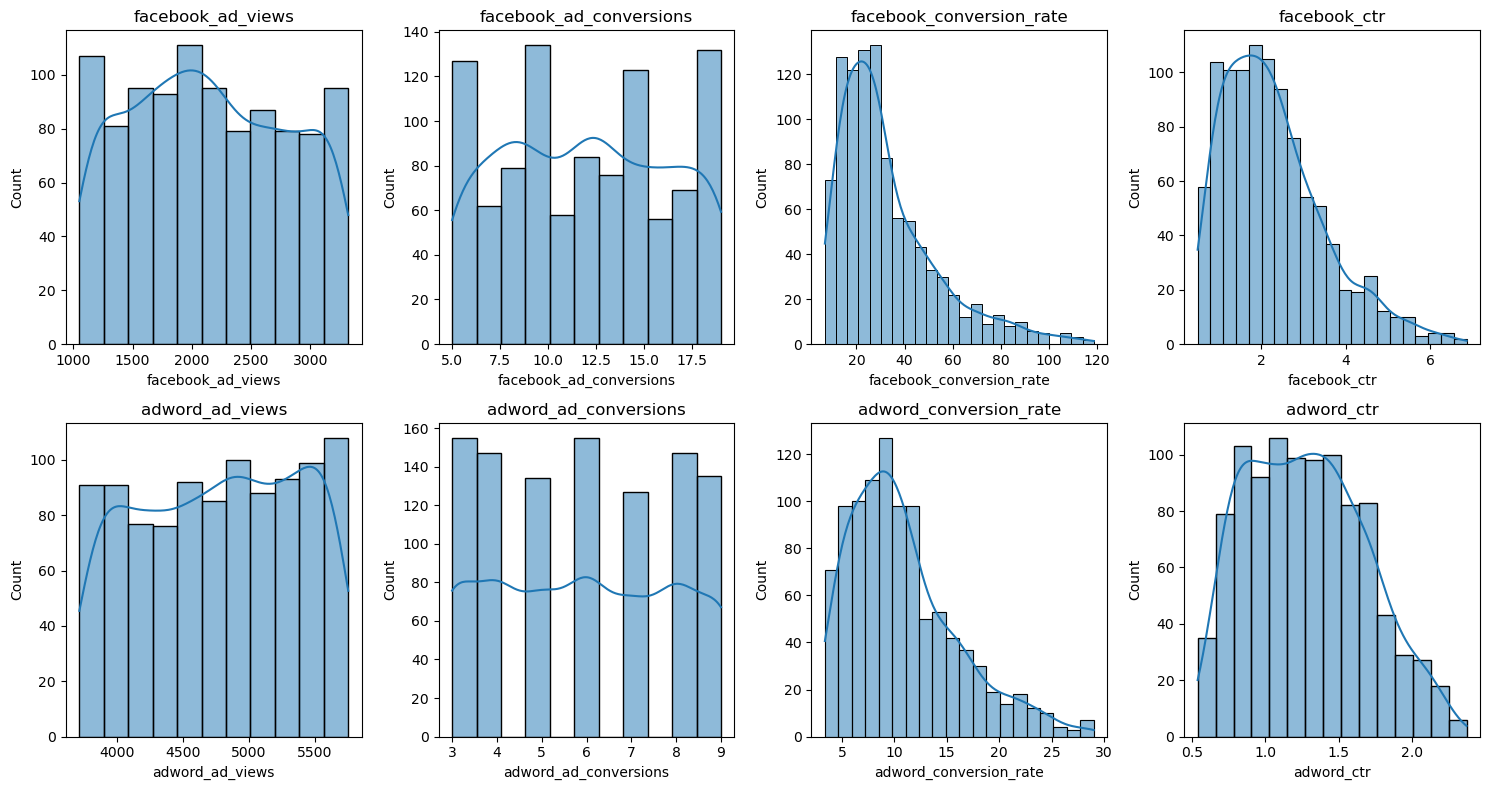

In [11]:
cols = ["facebook_ad_views","facebook_ad_conversions","facebook_conversion_rate","facebook_ctr","adword_ad_views","adword_ad_conversions", "adword_conversion_rate","adword_ctr"]

plt.figure(figsize=(15, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 4, i)         
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

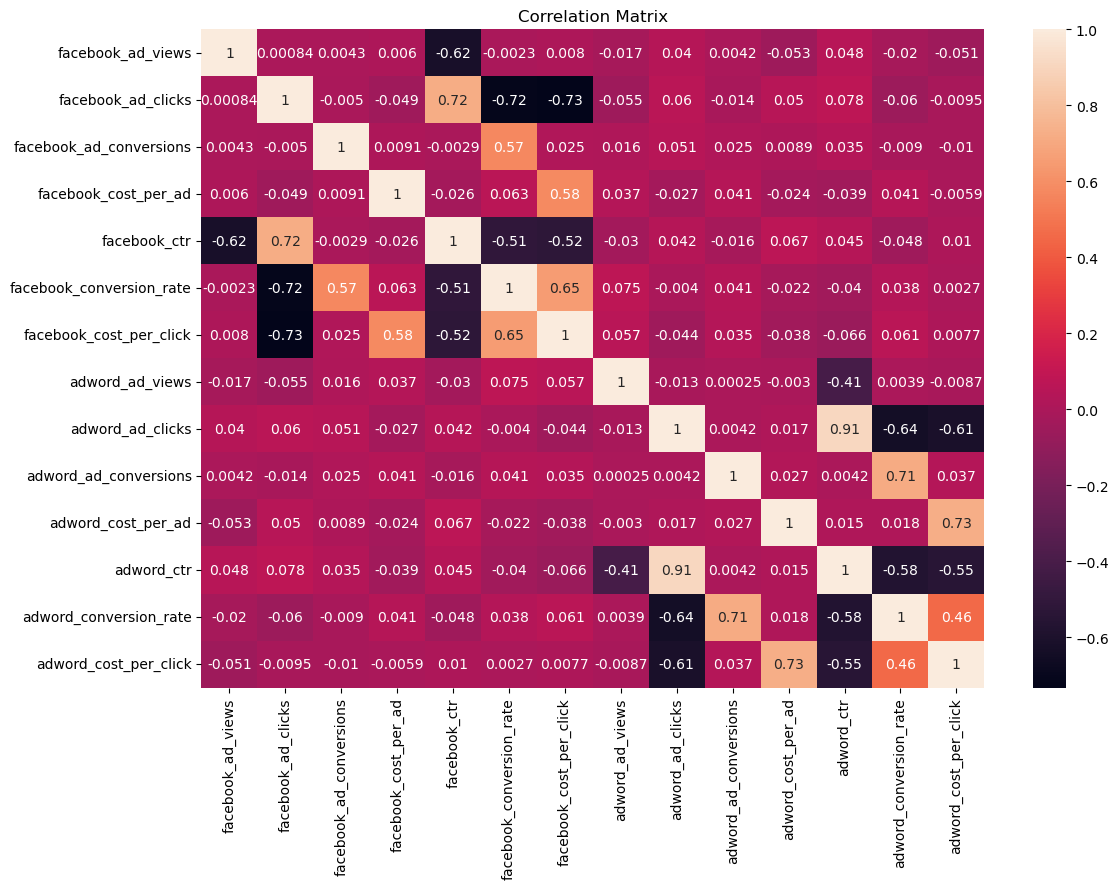

In [12]:
cols = ["facebook_ad_views", "facebook_ad_clicks", "facebook_ad_conversions",
            "facebook_cost_per_ad", "facebook_ctr", "facebook_conversion_rate", "facebook_cost_per_click",
            "adword_ad_views", "adword_ad_clicks", "adword_ad_conversions",
            "adword_cost_per_ad", "adword_ctr", "adword_conversion_rate", "adword_cost_per_click"]
plt.figure(figsize=(12, 9))
sns.heatmap(df[cols].corr(), annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## average conversion rate and average ctr (click trough rate) by each month for particular year

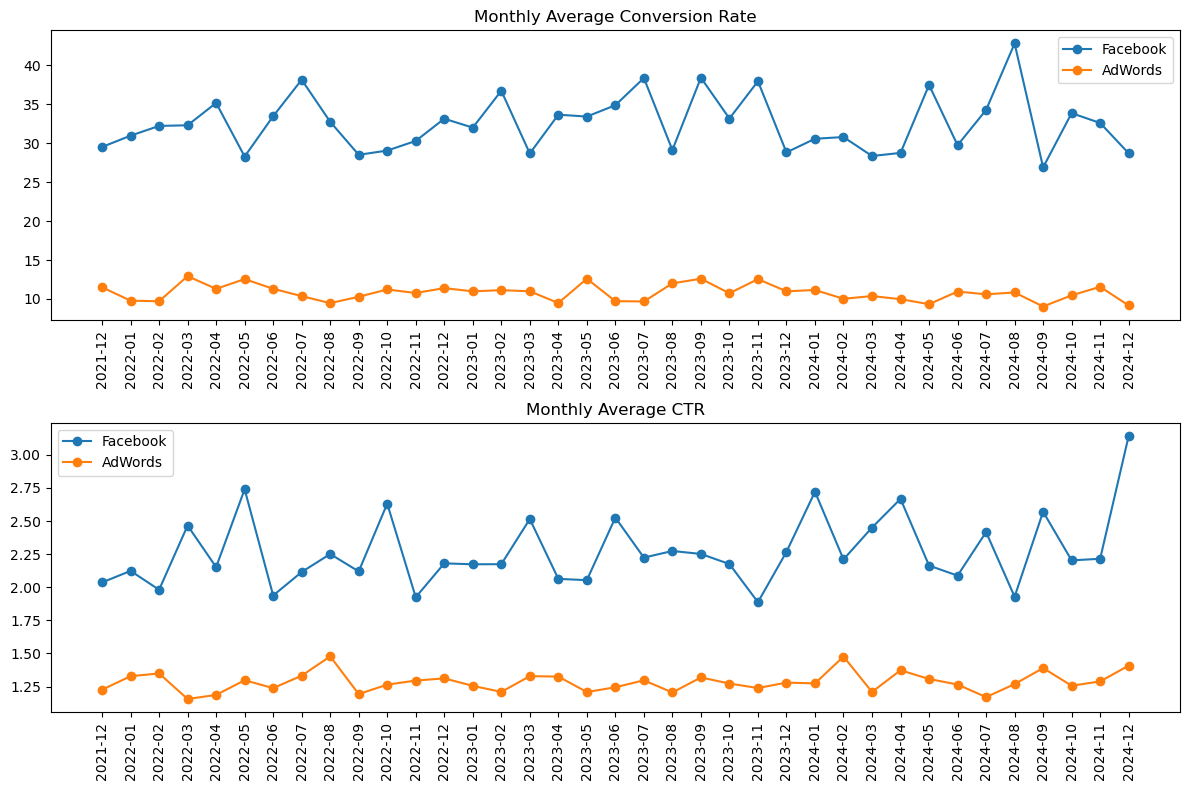

In [13]:
monthly = df.groupby("year_month").mean(numeric_only=True).reset_index()

plt.figure(figsize=(12,8))


plt.subplot(2,1,1)
plt.plot(monthly["year_month"], monthly["facebook_conversion_rate"], marker="o", label="Facebook")
plt.plot(monthly["year_month"], monthly["adword_conversion_rate"], marker="o", label="AdWords")
plt.title("Monthly Average Conversion Rate")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()


plt.subplot(2,1,2)
plt.plot(monthly["year_month"], monthly["facebook_ctr"], marker="o", label="Facebook")
plt.plot(monthly["year_month"], monthly["adword_ctr"], marker="o", label="AdWords")
plt.title("Monthly Average CTR")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## detailed Conversion Performance by each platform 

In [14]:
### Defined shared bins so both platforms are judged on the same absolute scale

bins = [0, 7, 13, 19]
labels = ["Low (0-7)", "Medium (8-13)", "High (14-19)"]

df["fb_conversion_category"] = pd.cut(df["facebook_ad_conversions"], bins=bins, labels=labels, include_lowest=True)
df["aw_conversion_category"] = pd.cut(df["adword_ad_conversions"], bins=bins, labels=labels, include_lowest=True)

fb_counts = df["fb_conversion_category"].value_counts().reindex(labels)
aw_counts = df["aw_conversion_category"].value_counts().reindex(labels)

category_comparison = pd.DataFrame({"Facebook": fb_counts, "AdWords": aw_counts})
category_comparison 

,Facebook,AdWords
Low (0-7),189,718
Medium (8-13),431,282
High (14-19),380,0


## Visualize category distribution of each platfrom side by side

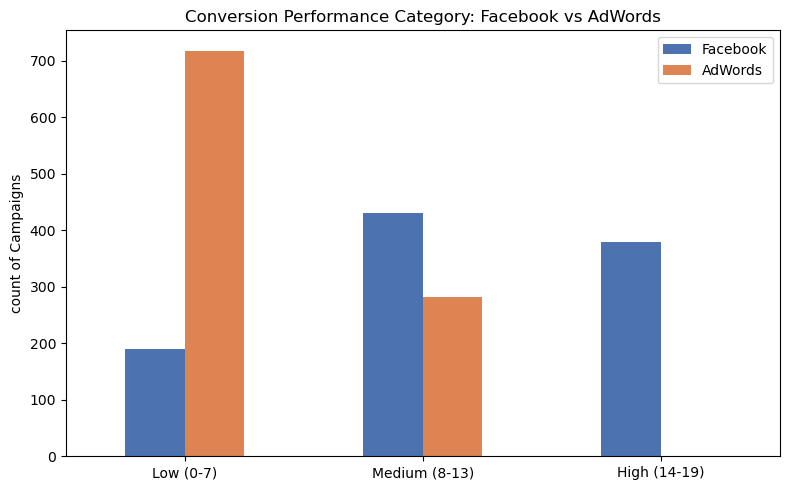

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
category_comparison.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("count of Campaigns")
ax.set_title("Conversion Performance Category: Facebook vs AdWords")
ax.set_xticklabels(labels, rotation=0)
plt.tight_layout()
plt.show() 

## Total AD conversion by each platfrom in last 3 years 

In [16]:
total = df[["facebook_ad_conversions", "adword_ad_conversions"]].sum()
total

facebook_ad_conversions    11975
adword_ad_conversions       5933
dtype: int64

## Share of Total Ad Conversions by each platform

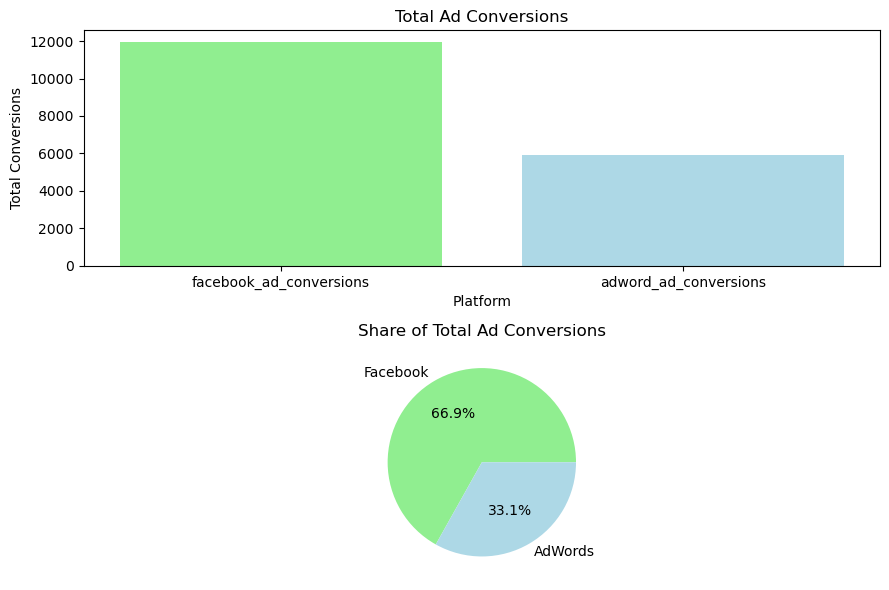

In [17]:
total = df[["facebook_ad_conversions", "adword_ad_conversions"]].sum()

plt.figure(figsize=(9,6))
plt.subplot(2,1,1)
colors=["lightgreen", "lightblue"]


plt.bar(total.index, total.values, color=colors)
plt.title("Total Ad Conversions")
plt.xlabel("Platform")
plt.ylabel("Total Conversions")



plt.subplot(2,1,2)
plt.pie(total.values,labels=["Facebook", "AdWords"], colors=colors,autopct="%1.1f%%")
plt.title("Share of Total Ad Conversions")
plt.tight_layout()

plt.show()

## Cost per Conversion: the single number that combines performance AND spend

In [18]:
df["fb_cost_per_conversion"] = df["facebook_cost_per_ad"] / df["facebook_ad_conversions"]
df["aw_cost_per_conversion"] = df["adword_cost_per_ad"] / df["adword_ad_conversions"]

cost_per_conversion = pd.DataFrame({
    "Platform": ["Facebook", "AdWords"],
    "Avg Cost per Conversion ($)": [
        round(df["fb_cost_per_conversion"].mean(), 2),
        round(df["aw_cost_per_conversion"].mean(), 2),
    ]
})
cost_per_conversion

,Platform,Avg Cost per Conversion ($)
0,Facebook,15.23
1,AdWords,23.97


## Closing visual for the stakeholder deck: Cost per Conversion 

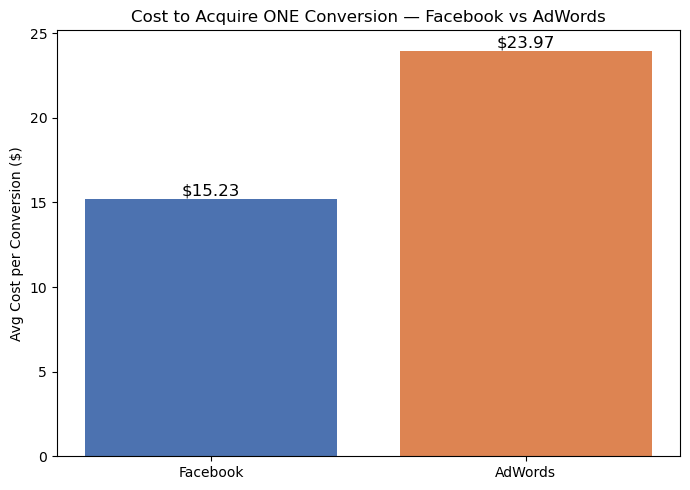

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(cost_per_conversion["Platform"], cost_per_conversion["Avg Cost per Conversion ($)"],
               color=["#4C72B0", "#DD8452"])
ax.bar_label(bars, fmt="$%.2f", fontsize=12)
ax.set_ylabel("Avg Cost per Conversion ($)")
ax.set_title("Cost to Acquire ONE Conversion — Facebook vs AdWords")
plt.tight_layout()
plt.show()

## Yearly Conversion Performance Summary(Average Ad conversion per day and Total Ad Conversions)

In [20]:
avg =df.groupby("year")[["facebook_ad_conversions", "adword_ad_conversions"]].mean().reset_index()
avg.columns = ["year","Avg_Facebook_Conversions_per_day","Avg_AdWords_Conversions_per_day"]

total_c= df.groupby("year")[["facebook_ad_conversions", "adword_ad_conversions"]].sum().reset_index()
total_c.columns = ["year","Total_Facebook_Conversions","Total_AdWords_Conversions"]

summary = pd.merge(avg, total_c, on="year")
summary


,year,Avg_Facebook_Conversions_per_day,Avg_AdWords_Conversions_per_day,Total_Facebook_Conversions,Total_AdWords_Conversions
0,2021,12.500000,6.125000,100,49
1,2022,11.529221,6.032468,3551,1858
2,2023,12.219298,5.976608,4179,2044
3,2024,12.119883,5.795322,4145,1982


<Figure size 800x500 with 0 Axes>

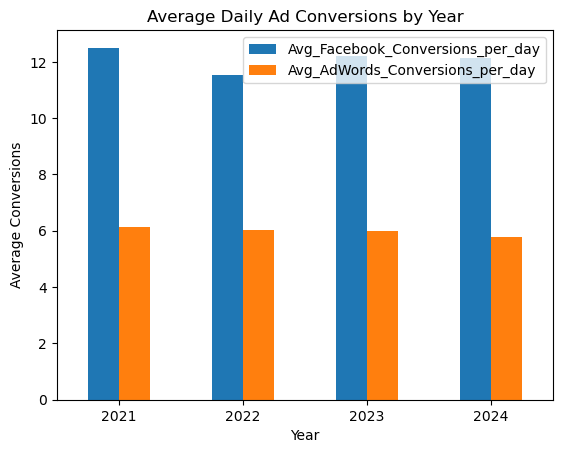

In [21]:
plt.figure(figsize=(8,5))

summary.plot(
    x="year",
    y=["Avg_Facebook_Conversions_per_day",
       "Avg_AdWords_Conversions_per_day"],
    kind="bar"
)

plt.title("Average Daily Ad Conversions by Year")
plt.xlabel("Year")
plt.ylabel("Average Conversions")
plt.xticks(rotation=0)

plt.show()

<Figure size 800x500 with 0 Axes>

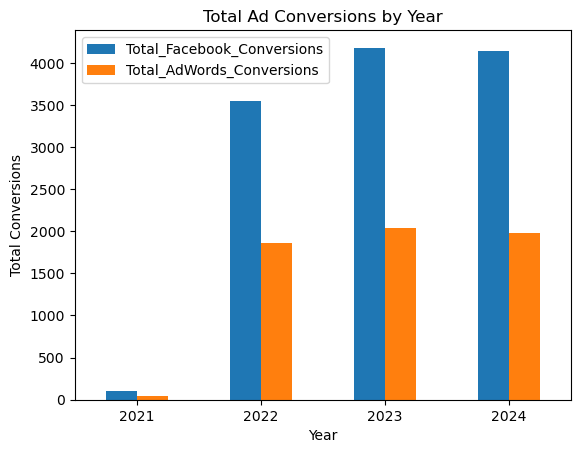

In [22]:
plt.figure(figsize=(8,5))

summary.plot(
    x="year",
    y=["Total_Facebook_Conversions",
       "Total_AdWords_Conversions"],
    kind="bar")

plt.title("Total Ad Conversions by Year")
plt.xlabel("Year")
plt.ylabel("Total Conversions")
plt.xticks(rotation=0)

plt.show()

In [23]:
insight_summary = pd.DataFrame([
    {"Metric": "Views per Campaign",
     "Facebook (avg)": f"{df['facebook_ad_views'].mean():,.0f}",
     "AdWords (avg)": f"{df['adword_ad_views'].mean():,.0f}",
     "Observed Pattern": "AdWords gets ~2x more impressions"},
    
    {"Metric": "CTR",
     "Facebook (avg)": f"{df['facebook_ctr'].mean():.2f}%",
     "AdWords (avg)": f"{df['adword_ctr'].mean():.2f}%",
     "Observed Pattern": "Facebook ads are clicked more, despite fewer views"},

    {"Metric": "Conversion Rate",
     "Facebook (avg)": f"{df['facebook_conversion_rate'].mean():.1f}%",
     "AdWords (avg)": f"{df['adword_conversion_rate'].mean():.1f}%",
     "Observed Pattern": "Facebook converts clicks into results ~3x better"},

    {"Metric": "Cost per Click",
     "Facebook (avg)": f"${df['facebook_cost_per_click'].mean():.2f}",
     "AdWords (avg)": f"${df['adword_cost_per_click'].mean():.2f}",
     "Observed Pattern": "AdWords clicks are cheaper"},

    {"Metric": "Conversions per Campaign",
     "Facebook (avg)": f"{df['facebook_ad_conversions'].mean():.2f}",
     "AdWords (avg)": f"{df['adword_ad_conversions'].mean():.2f}",
     "Observed Pattern": "Facebook delivers ~2x more conversions per campaign"},

    {"Metric": "Cost per Conversion",
     "Facebook (avg)": f"${df['fb_cost_per_conversion'].mean():.2f}",
     "AdWords (avg)": f"${df['aw_cost_per_conversion'].mean():.2f}",
     "Observed Pattern": "Facebook is actually cheaper per result, despite pricier clicks"},

    {"Metric": '% Campaigns in "High" tier',
     "Facebook (avg)": f"{(df['fb_conversion_category']=='High (14-19)').mean()*100:.0f}%",
     "AdWords (avg)": f"{(df['aw_conversion_category']=='High (14-19)').mean()*100:.0f}%",
     "Observed Pattern": "AdWords never produces a top-tier campaign"},
])



insight_summary

,Metric,Facebook (avg),AdWords (avg),Observed Pattern
0,Views per Campaign,"2,152","4,771",AdWords gets ~2x more impressions
1,CTR,2.28%,1.28%,"Facebook ads are clicked more, despite fewer v..."
2,Conversion Rate,32.7%,10.8%,Facebook converts clicks into results ~3x better
3,Cost per Click,$4.31,$2.27,AdWords clicks are cheaper
4,Conversions per Campaign,11.97,5.93,Facebook delivers ~2x more conversions per cam...
5,Cost per Conversion,$15.23,$23.97,"Facebook is actually cheaper per result, despi..."
6,"% Campaigns in ""High"" tier",38%,0%,AdWords never produces a top-tier campaign


# Key observation: 
## AdWords wins on volume (views) and click price  , but loses everywhere that reflects actual outcomes (CTR, conversion rate, total conversions, cost-per-result).So Facebook overally delivers more and better results 
## But this is not statistically confirmed yet that the difference between the 2 platform is real and not random ,so we will run A/B testing to observe that, "Does the choice of ad platform (Facebook vs AdWords) make a real difference to each metric ?"
## 

In [24]:
metrics = [("CTR (%)", "facebook_ctr", "adword_ctr"),("Conversion Rate (%)", "facebook_conversion_rate", "adword_conversion_rate"),
           ("Cost per Click ($)", "facebook_cost_per_click", "adword_cost_per_click"),
           ("Conversions per Campaign", "facebook_ad_conversions", "adword_ad_conversions"),
           ("Cost per Conversion ($)", "fb_cost_per_conversion", "aw_cost_per_conversion")]

In [25]:
results = []
for label, fb_col, aw_col in metrics:
    facebook = df[fb_col]
    adwords = df[aw_col]

# normality Check
    fb_normal = stats.normaltest(facebook).pvalue > 0.05
    aw_normal = stats.normaltest(adwords).pvalue > 0.05

# equal variance Check
    equal_var = stats.levene(facebook, adwords).pvalue > 0.05

#statistical test Selection 
    if fb_normal and aw_normal:
        stat, p_value = stats.ttest_ind(facebook, adwords, equal_var=equal_var)
        test = "t-test" 
    else:
        stat, p_value = stats.mannwhitneyu(facebook, adwords, alternative="two-sided")
        test = "Mann-Whitney U"
    
    print(f"\n{'='*60}")
    print(f"Metric: {label}")
    print("H0: There is no significant difference between Facebook and AdWords")
    print("H1: There is a significant difference between Facebook and AdWords.")

    if p_value < 0.05:
        print("Decision: Reject H0")
    else:
        print("Decision: Fail to Reject H0")

    print(f"Test Used: {test}")
    print(f"Test Statistic: {stat:.3f}")
    print(f"P-value: {p_value:.6f}")
    print(f"{'='*60}")

# Decide better performer
    if label in ["Cost per Click ($)", "Cost per Conversion ($)"]:
        better = "Facebook" if facebook.mean() < adwords.mean() else "AdWords"
    else:
        better = "Facebook" if facebook.mean() > adwords.mean() else "AdWords"
# Store result
    results.append({
    "Metric": label,
    "Facebook Mean": round(facebook.mean(),3),
    "AdWords Mean": round(adwords.mean(),3),
    "Test Used": test,
    "Test statistic": round(stat,3),
    "p-value": round(p_value,6),
    "Significant": p_value < 0.05,
    "Better Performer": better
})
ab_results = pd.DataFrame(results)
ab_results


Metric: CTR (%)
H0: There is no significant difference between Facebook and AdWords
H1: There is a significant difference between Facebook and AdWords.
Decision: Reject H0
Test Used: Mann-Whitney U
Test Statistic: 775227.500
P-value: 0.000000

Metric: Conversion Rate (%)
H0: There is no significant difference between Facebook and AdWords
H1: There is a significant difference between Facebook and AdWords.
Decision: Reject H0
Test Used: Mann-Whitney U
Test Statistic: 915323.500
P-value: 0.000000

Metric: Cost per Click ($)
H0: There is no significant difference between Facebook and AdWords
H1: There is a significant difference between Facebook and AdWords.
Decision: Reject H0
Test Used: Mann-Whitney U
Test Statistic: 765488.500
P-value: 0.000000

Metric: Conversions per Campaign
H0: There is no significant difference between Facebook and AdWords
H1: There is a significant difference between Facebook and AdWords.
Decision: Reject H0
Test Used: Mann-Whitney U
Test Statistic: 886002.000
P-

,Metric,Facebook Mean,AdWords Mean,Test Used,Test statistic,p-value,Significant,Better Performer
0,CTR (%),2.283,1.281,Mann-Whitney U,775227.5,0.0,True,Facebook
1,Conversion Rate (%),32.696,10.808,Mann-Whitney U,915323.5,0.0,True,Facebook
2,Cost per Click ($),4.310,2.266,Mann-Whitney U,765488.5,0.0,True,AdWords
3,Conversions per Campaign,11.975,5.933,Mann-Whitney U,886002.0,0.0,True,Facebook
4,Cost per Conversion ($),15.229,23.974,Mann-Whitney U,274470.5,0.0,True,Facebook


## Since the significant difference between the perfomance of both the platform is True for each of the metric i.e the observed gap is not due to random chance and is real, therefore we are rejecting the null hypothesis
## From the above analysis we can mark that facebook gives the better ROI interms of CTR, conversion rate, per day converssion, & Cost per Conversion where as AdWords gets ~2x more impressions & have low cost per click   
## So prioritize Facebook for conversion-focused campaigns, use AdWords when the goal is cheap reach/awareness